In [1]:
import os
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
nstep = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
nstep = nstep[2:].reset_index(drop = True)
nstep.columns = ["Batch"] + nstep.columns.tolist()[1:]

nstep_ts = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
nstep_ts.insert(0, "Batch", nstep_ts["Run"].apply(lambda x: x.split("_")[0]))

nstep_ts_start = nstep_ts[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nstep_ts_start.columns = ["Batch", "Process Start Time"]

nstep_ts = pd.merge(nstep_ts_start, nstep_ts, on = "Batch")
nstep_ts["Process Time [h]"] -= nstep_ts["Process Start Time"]
nstep_ts.insert(3, "Process Day", nstep_ts["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nstep_ts.drop("Process Start Time", axis = 1, inplace = True)

In [3]:
important_tags = [
    'STR2K_D05_2_1_PA_HPLC_Concentration',
    'STR2K_D14_4_1_PA_HPLC_Concentration'
]

In [4]:
nstep_ts.head(2)

,Batch,Run,Process Day,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,FA001_MCALR N-PROD 2000L_1003145,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001,FA001_MCALR N-PROD 2000L_1003145,0,0.003056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN


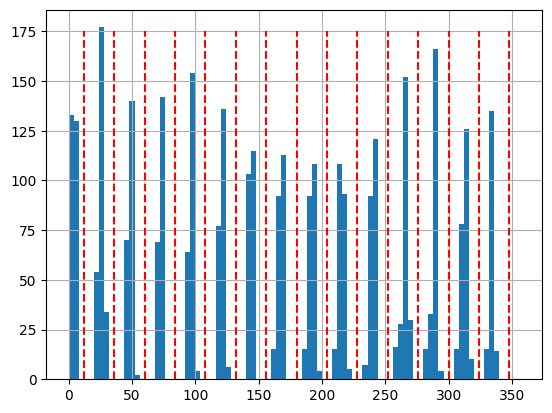

In [5]:
nstep_ts["Process Time [h]"].hist(bins = [4 * i for i in range(90)])
lines = [(i * 24) + 12 for i in range(15)]
plt.vlines(lines, 0, 175, linestyle = '--', color = 'red')

In [6]:
daily_nstep = nstep_ts.drop(["Run", "Process Time [h]"], axis = 1).groupby(["Batch", "Process Day"]).mean().reset_index()
daily_nstep = daily_nstep[daily_nstep["Batch"].isin([f"FA{str(i).zfill(3)}" for i in range(6, 12)])]
daily_nstep

,Batch,Process Day,Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
75,FA006,0,2.909,46.52,NaN,4.651,4873.43,107.87,12.18,0.101,256.33,132.05,7.053,7.035,7.025,89.45,-0.079639,93.25,6.36,87.3
76,FA006,1,38.072,46.50,NaN,4.652,3790.47,458.16,37.79,0.100,2303.13,297.90,6.818,6.915,6.915,33.55,0.037596,37.70,11.80,88.3
77,FA006,2,34.962,46.50,NaN,4.652,3712.89,639.16,42.38,0.111,1864.94,425.65,6.824,6.870,6.860,39.20,-0.013751,10.00,20.49,90.8
78,FA006,3,27.338,46.52,NaN,4.651,3219.31,698.50,72.59,0.222,1633.33,576.60,6.862,6.950,6.950,52.50,0.028396,10.00,24.47,91.2
79,FA006,4,27.087,46.52,NaN,4.651,2354.62,591.55,135.41,0.497,124.70,773.65,6.950,7.030,7.020,60.00,0.020279,10.00,27.46,90.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,FA011,10,136.388,46.40,12.60,4.635,1417.70,201.47,917.60,3.888,270.64,3238.65,6.990,7.050,7.050,150.00,0.000020,10.00,19.36,67.2
161,FA011,11,130.870,46.40,NaN,4.634,2989.85,288.58,1089.46,4.270,663.81,3523.60,6.960,7.040,7.030,130.20,NaN,10.00,17.35,62.0
162,FA011,12,120.286,46.40,14.62,4.636,1218.24,367.30,1255.74,4.658,1084.11,3961.35,6.938,7.030,7.030,92.80,NaN,14.40,17.28,57.0
163,FA011,13,111.709,46.40,10.09,4.634,2351.06,463.96,1402.63,5.068,2617.30,4246.50,6.691,6.870,6.870,38.55,NaN,21.40,14.00,49.6


In [7]:
correlations = []
target = "STR2K_D14_4_1_PA_HPLC_Concentration"
for day in daily_nstep["Process Day"].unique():
    sub_df = daily_nstep[daily_nstep["Process Day"] == day]
    for col in sub_df.columns[2:]:
        subsub_df = sub_df[["Batch", col]]
        subsub_df = pd.merge(subsub_df, nstep[["Batch", target]], on = "Batch")
        try:
            corr = np.corrcoef(subsub_df[col].tolist(), subsub_df[target].tolist())[0, 1]
        except:
            corr = np.nan
        correlations.append([col, day, corr])
corr_df = pd.DataFrame(correlations, columns = ["Feature", "Day", "Correlation"])
corr_df["Abs Corr"] = corr_df["Correlation"].abs()
corr_df["Abs Corr"].fillna(0, inplace = True)
corr_df

/home/ubuntu/.virtualenvs/base/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ubuntu/.virtualenvs/base/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ubuntu/.virtualenvs/base/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ubuntu/.virtualenvs/base/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ubuntu/.virtualenvs/base/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ubuntu/.virtualenvs/base/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value e

,Feature,Day,Correlation,Abs Corr
0,Ammonia [mg/L],0,-0.350293,0.350293
1,Bolus Feed A Daily Qty [kg],0,0.523718,0.523718
2,Bolus Glucose Daily Qty [kg],0,NaN,0.000000
3,Bolus Feed B Daily Qty [kg],0,0.500391,0.500391
4,Glucose [mg/L],0,-0.041783,0.041783
...,...,...,...,...
265,pCO2 preadusjtement [mmHg],14,-0.076567,0.076567
266,pH offset [],14,NaN,0.000000
267,pO2 preadusjtement [mmHg],14,0.060766,0.060766
268,VCD [Mc/mL],14,0.888204,0.888204


In [8]:
corr_df.sort_values(by = "Abs Corr", ascending = False).reset_index(drop = True).reset_index().groupby("Feature").mean().sort_values(by = "index")

,index,Day,Correlation,Abs Corr
Feature,,,,
Glutamate [mg/L],84.000000,7.0,-0.593611,0.634161
VCD [Mc/mL],93.266667,7.0,0.506435,0.592499
Viability [%],97.200000,7.0,-0.003338,0.573866
IgG [g/L],105.666667,7.0,0.547823,0.547823
Bolus Feed B Daily Qty [kg],107.600000,7.0,0.558965,0.521701
LDH [dimensionless],110.800000,7.0,0.133791,0.525458
Lactate [mg/L],111.200000,7.0,-0.382772,0.536831
Glutamine [mg/L],111.733333,7.0,-0.085916,0.522266
Online pH primary probe preadusjtement [dimensionless],112.600000,7.0,0.365709,0.515895


/tmp/ipykernel_192335/3910101239.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  qwe = corr_df[corr_df["Day"] <= 8][corr_df["Feature"] == tag]


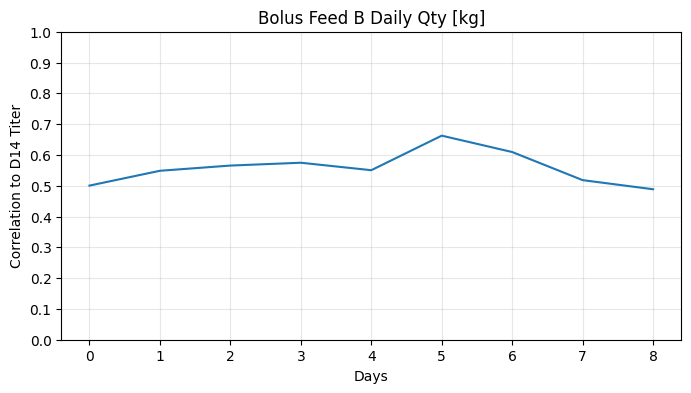

In [9]:
tag = "Bolus Feed B Daily Qty [kg]"
qwe = corr_df[corr_df["Day"] <= 8][corr_df["Feature"] == tag]

plt.figure(figsize = (8, 4))
plt.plot(qwe["Day"], qwe["Correlation"])
plt.title(tag)
plt.ylabel("Correlation to D14 Titer")
plt.xlabel("Days")
plt.ylim(0, 1.0)
plt.yticks([i * 0.1 for i in range(0, 11)])
plt.grid(alpha = 0.3)

/tmp/ipykernel_192335/1486084599.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  qwe = corr_df[corr_df["Day"] <= 8][corr_df["Feature"] == tag]


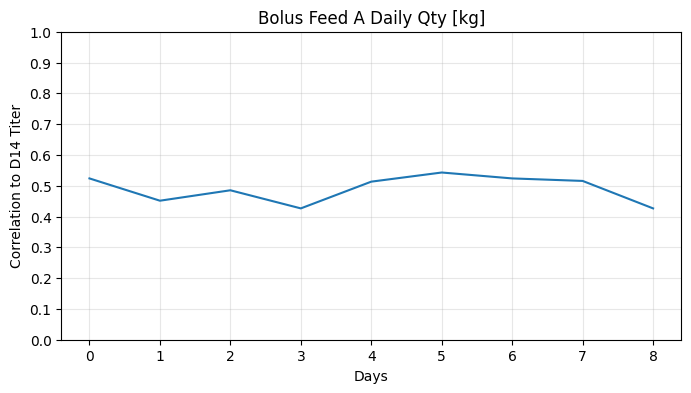

In [10]:
tag = "Bolus Feed A Daily Qty [kg]"
qwe = corr_df[corr_df["Day"] <= 8][corr_df["Feature"] == tag]

plt.figure(figsize = (8, 4))
plt.plot(qwe["Day"], qwe["Correlation"])
plt.title(tag)
plt.ylabel("Correlation to D14 Titer")
plt.xlabel("Days")
plt.ylim(0, 1.0)
plt.yticks([i * 0.1 for i in range(0, 11)])
plt.grid(alpha = 0.3)

/tmp/ipykernel_192335/3556917954.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  qwe = corr_df[corr_df["Day"] <= 8][corr_df["Feature"] == "LDH [dimensionless]"]


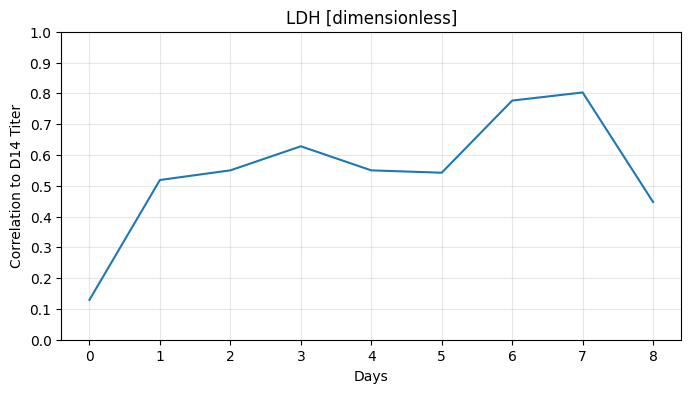

In [11]:
qwe = corr_df[corr_df["Day"] <= 8][corr_df["Feature"] == "LDH [dimensionless]"]

plt.figure(figsize = (8, 4))
plt.plot(qwe["Day"], qwe["Correlation"])
plt.title("LDH [dimensionless]")
plt.ylabel("Correlation to D14 Titer")
plt.xlabel("Days")
plt.ylim(0, 1.0)
plt.yticks([i * 0.1 for i in range(0, 11)])
plt.grid(alpha = 0.3)
plt.savefig("./raphael_req/ldh_daily.png")

In [12]:
ldh = nstep_ts[~nstep_ts["LDH [dimensionless]"].isna()][["Batch", "Process Day", "Process Time [h]", "LDH [dimensionless]"]].copy()

ldh

,Batch,Process Day,Process Time [h],LDH [dimensionless]
17,FA001,0,6.118333,110.0
18,FA001,0,6.121389,113.8
35,FA001,1,24.829167,360.9
36,FA001,1,24.832222,362.3
58,FA001,2,49.005833,560.5
...,...,...,...,...
3279,FA011,12,286.885833,3070.0
3303,FA011,13,311.975833,5296.8
3304,FA011,13,311.978611,3196.2
3325,FA011,14,334.978889,5893.5


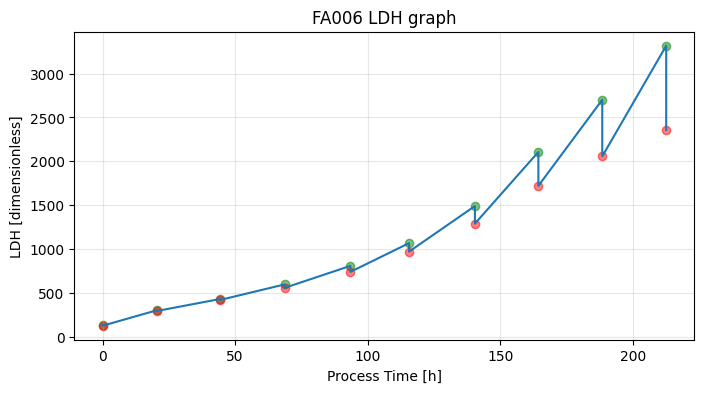

In [13]:
qwe = nstep_ts[(nstep_ts["Batch"] == "FA006") & (~nstep_ts["LDH [dimensionless]"].isna())][["Batch", "Process Time [h]", "LDH [dimensionless]"]].copy()
qwe["Process Time [h]"] = qwe["Process Time [h]"] - qwe["Process Time [h]"].min()
qwe = qwe[qwe["Process Time [h]"] < (24 * 9)]

plt.figure(figsize = (8, 4))
plt.plot(qwe["Process Time [h]"], qwe["LDH [dimensionless]"])

qwe = nstep_ts[(nstep_ts["Batch"] == "FA006") & (~nstep_ts["LDH [dimensionless]"].isna())][["Batch", "Process Day", "Process Time [h]", "LDH [dimensionless]"]].copy()
qwe["Process Time [h]"] = qwe["Process Time [h]"] - qwe["Process Time [h]"].min()
qwe = qwe.drop_duplicates(["Batch", "Process Day"], keep = "first")
qwe = qwe[qwe["Process Time [h]"] < (24 * 9)]

plt.scatter(qwe["Process Time [h]"], qwe["LDH [dimensionless]"], c = "green", alpha = 0.5)


qwe = nstep_ts[(nstep_ts["Batch"] == "FA006") & (~nstep_ts["LDH [dimensionless]"].isna())][["Batch", "Process Day", "Process Time [h]", "LDH [dimensionless]"]].copy()
qwe["Process Time [h]"] = qwe["Process Time [h]"] - qwe["Process Time [h]"].min()
qwe = qwe.drop_duplicates(["Batch", "Process Day"], keep = "last")
qwe = qwe[qwe["Process Time [h]"] < (24 * 9)]

plt.scatter(qwe["Process Time [h]"], qwe["LDH [dimensionless]"], c = "red", alpha = 0.5)

plt.grid(alpha = 0.3)
plt.ylabel("LDH [dimensionless]")
plt.xlabel("Process Time [h]")
plt.title("FA006 LDH graph")
plt.show()

In [47]:
feat = "LDH [dimensionless]"

ldh = nstep_ts[["Batch", "Process Day", "Process Time [h]", feat]].copy()
ldh = ldh[~ldh[feat].isna()]
ldh = ldh.drop("Process Time [h]", axis = 1)
# ldh = ldh[ldh["Batch"].isin([f"FA{str(i).zfill(3)}" for i in range(6, 12)])]

ldh_max = ldh.drop_duplicates(["Batch", "Process Day"], keep = "first").reset_index(drop = True)
ldh_min = ldh.drop_duplicates(["Batch", "Process Day"], keep = "last").reset_index(drop = True)

ldh_dif = ldh_max.copy()
ldh_dif[feat] = ldh_max[feat] - ldh_min[feat]

ldh_ave = ldh_max.copy()
ldh_ave[feat] = (ldh_max[feat] + ldh_min[feat]) / 2

ldh_f4 = ldh[ldh["Process Day"] <= 4]
ldh_f4 = ldh_f4.groupby(["Batch"]).mean().reset_index()

ldh_f4to8 = ldh[(ldh["Process Day"] >= 4) & (ldh["Process Day"] <= 8)]
ldh_f4to8 = ldh_f4to8.groupby(["Batch"]).mean().reset_index()

ldh_f8 = ldh[(ldh["Process Day"] <= 8)]
ldh_f8 = ldh_f8.groupby(["Batch"]).mean().reset_index()

ldh

,Batch,Process Day,LDH [dimensionless]
17,FA001,0,110.0
18,FA001,0,113.8
35,FA001,1,360.9
36,FA001,1,362.3
58,FA001,2,560.5
...,...,...,...
3279,FA011,12,3070.0
3303,FA011,13,5296.8
3304,FA011,13,3196.2
3325,FA011,14,5893.5


In [48]:
ldh_df["Process Day"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

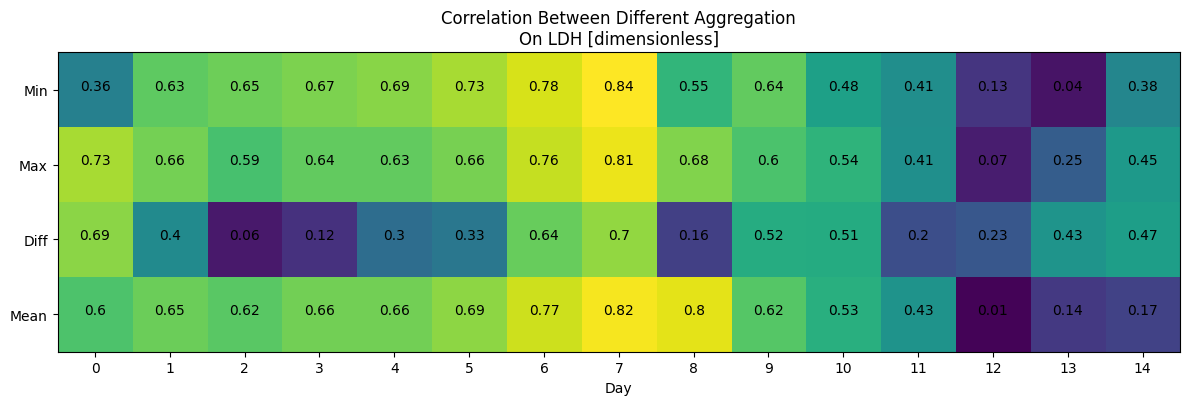

In [49]:
corr_matrix = np.zeros((4, 15))
dfs = [
    ldh_min, ldh_max, ldh_dif, ldh_ave
]

target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"].tolist()

for ldh_idx, ldh_df in enumerate(dfs):
    for day in ldh["Process Day"].unique():
        try:
            X = ldh_df[ldh_df["Process Day"] == day][feat].tolist()
            corr = np.corrcoef(X, target)[0, 1]
            corr_matrix[ldh_idx, day] = abs(corr)
        except:
            pass

plt.figure(figsize = (12, 5))
plt.yticks([0, 1, 2, 3], ["Min", "Max", "Diff", "Mean"])
plt.xticks(range(15))
plt.imshow(corr_matrix, vmin = 0.)

for row_idx in range(corr_matrix.shape[0]):
    for col_idx in range(corr_matrix.shape[1]):
        plt.text(col_idx, row_idx, round(corr_matrix[row_idx, col_idx], 2), horizontalalignment = "center")
plt.xlabel("Day")
plt.title(f"Correlation Between Different Aggregation\nOn {feat}")
plt.tight_layout()
plt.show()

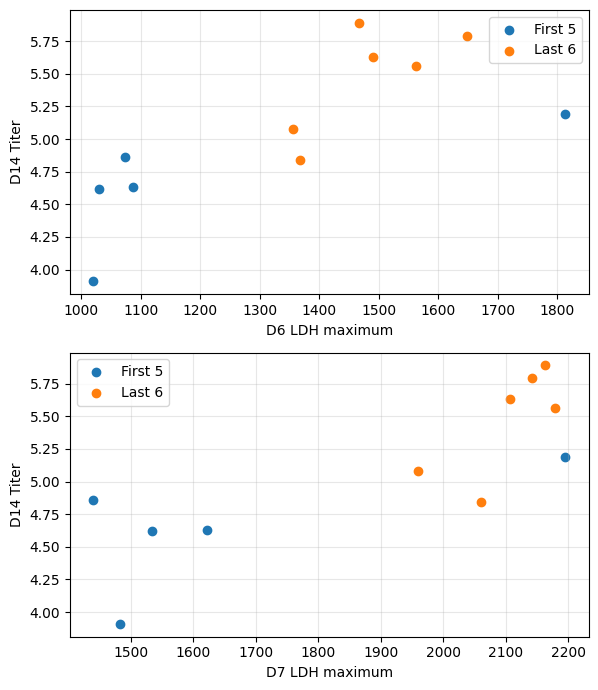

In [18]:
ldh[ldh["Process Day"] == 6].groupby("Batch").max().reset_index()

fig, axs = plt.subplots(2, 1, figsize = (6, 7))

ax = axs[0]
qwe = ldh[ldh["Process Day"] == 6].groupby("Batch").max().reset_index()
ax.scatter(qwe["LDH [dimensionless]"][:5], target[:5], label = "First 5")
ax.scatter(qwe["LDH [dimensionless]"][5:], target[5:], label = "Last 6")
ax.set_ylabel("D14 Titer")
ax.set_xlabel("D6 LDH maximum")
ax.grid(alpha = 0.3)
ax.legend()

ax = axs[1]
qwe = ldh[ldh["Process Day"] == 7].groupby("Batch").max().reset_index()
ax.scatter(qwe["LDH [dimensionless]"][:5], target[:5], label = "First 5")
ax.scatter(qwe["LDH [dimensionless]"][5:], target[5:], label = "Last 6")
ax.set_ylabel("D14 Titer")
ax.set_xlabel("D7 LDH maximum")
ax.grid(alpha = 0.3)
ax.legend()

fig.tight_layout()

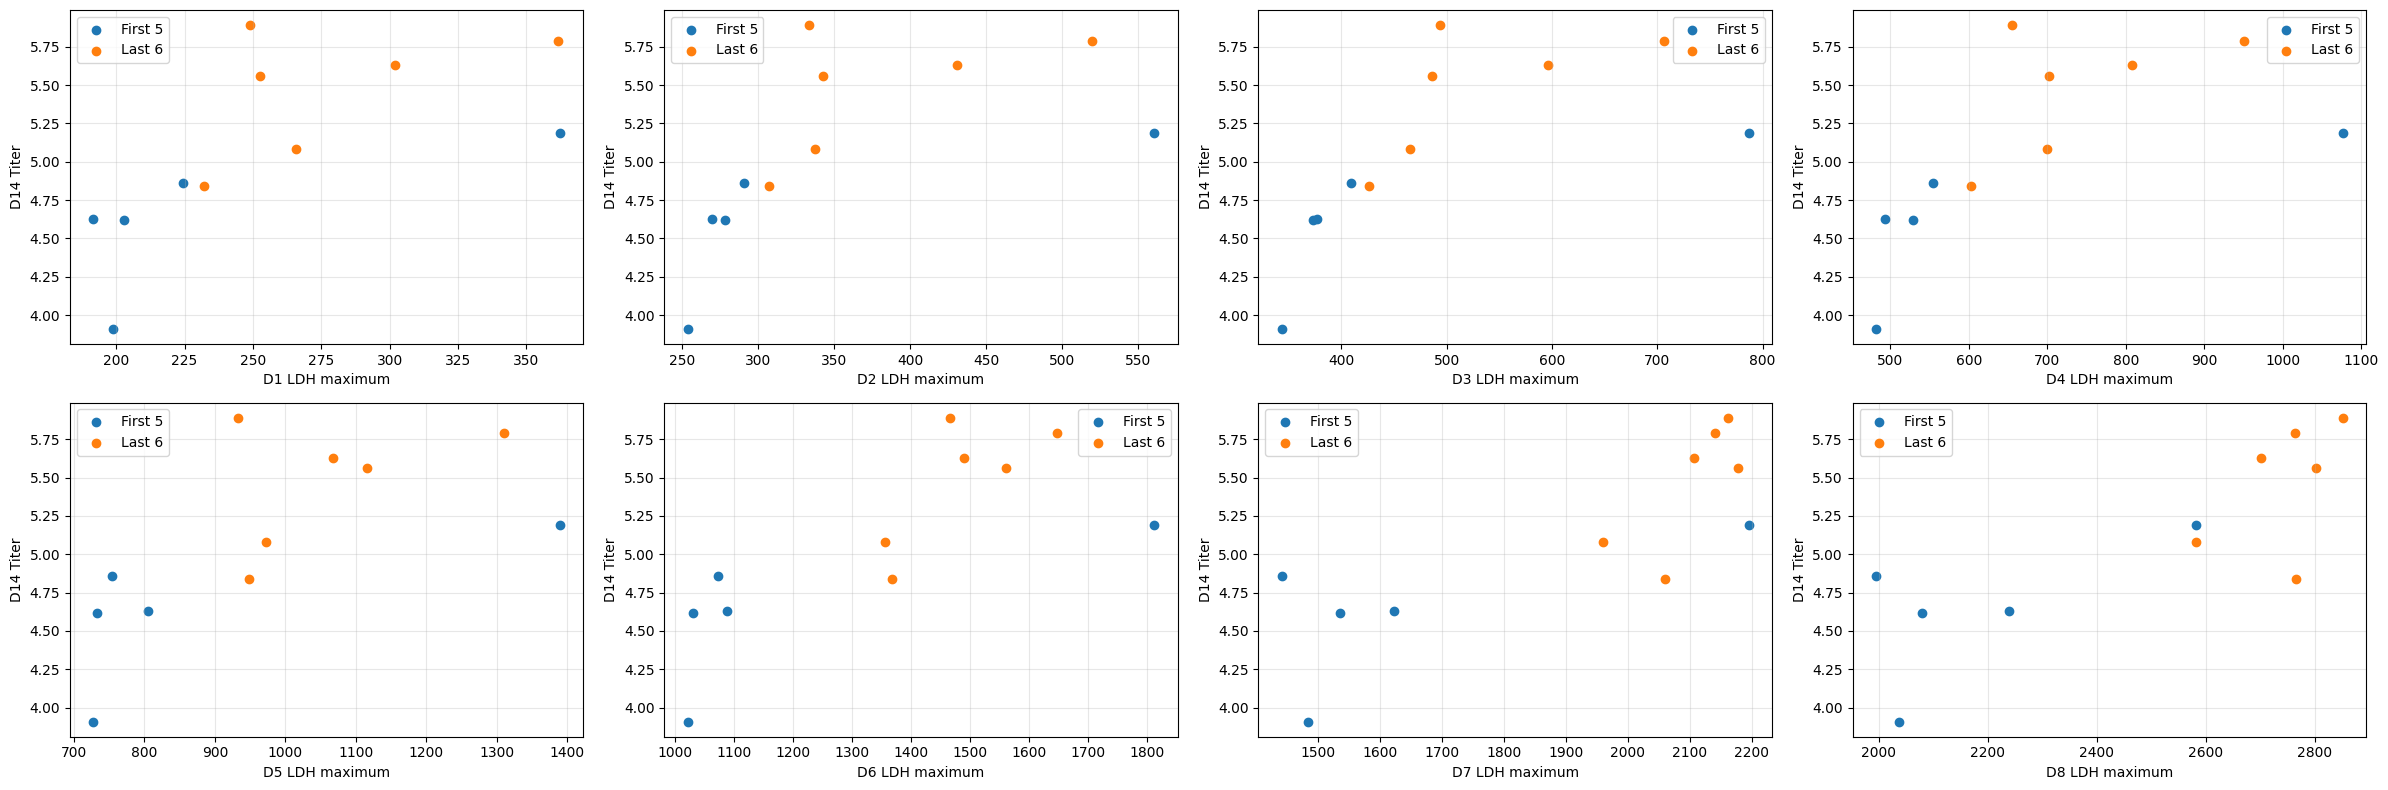

In [19]:
ldh[ldh["Process Day"] == 6].groupby("Batch").min().reset_index()

fig, axs = plt.subplots(2, 4, figsize = (24, 8))

for i in range(8):
    ax = axs[i // 4, i % 4]
    qwe = ldh[ldh["Process Day"] == i + 1].groupby("Batch").max().reset_index()
    ax.scatter(qwe["LDH [dimensionless]"][:5], target[:5], label = "First 5")
    ax.scatter(qwe["LDH [dimensionless]"][5:], target[5:], label = "Last 6")
    ax.set_ylabel("D14 Titer")
    ax.set_xlabel(f"D{i+1} LDH maximum")
    ax.grid(alpha = 0.3)
    ax.legend()
    
    # ax = axs[1]
    # qwe = ldh[ldh["Process Day"] == 7].groupby("Batch").min().reset_index()
    # ax.scatter(qwe["LDH [dimensionless]"][:5], target[:5], label = "First 5")
    # ax.scatter(qwe["LDH [dimensionless]"][5:], target[5:], label = "Last 6")
    # ax.set_ylabel("D14 Titer")
    # ax.set_xlabel("D7 LDH minimum")
    # ax.grid(alpha = 0.3)
    # ax.legend()
    
fig.tight_layout()

In [20]:
ivcd = pd.read_csv("./data/IVCD mCALR batches.csv", header = 1).T[1:].reset_index()
ivcd.columns = ["Batch"] + [f"Day {i+1}" for i in range(14)]
ivcd

,Batch,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14
0,FA001,7.910000,23.620000,43.640000,66.900000,90.280000,111.370000,131.690000,151.940000,171.290000,189.870000,209.280000,224.790000,240.530000,254.260000
1,FA002,7.526333,23.780990,47.801740,71.747344,96.022340,119.981715,145.173937,168.595042,191.285403,213.206292,234.256365,254.791795,274.193733,287.869389
2,FA003,8.397108,23.176253,43.769483,68.033330,95.031434,118.394205,142.100122,163.767955,184.343191,205.485965,224.121389,241.827951,255.410243,268.106521
3,FA004,7.875312,23.144076,43.868733,69.970358,98.432941,127.634316,153.067795,176.971701,198.975410,218.698656,239.793740,254.225184,267.430996,278.970997
4,FA005,10.348941,26.025278,49.839278,75.440194,101.347476,128.311264,151.639493,173.769851,195.245986,213.949194,230.402465,244.080507,254.594743,263.270632
5,FA006,7.793667,23.815337,46.451448,73.336042,98.385833,125.211194,149.829799,172.953729,194.834441,215.095708,235.089215,252.541785,266.884892,280.817809
6,FA007,9.870514,29.234493,55.608438,85.734882,115.396104,139.020233,164.783344,188.620979,211.029201,233.263754,258.606212,274.900535,292.086871,308.743653
7,FA008,8.669677,21.587490,42.696948,67.021156,93.864656,120.384792,144.636156,168.653760,190.536865,210.286573,229.953948,245.853295,260.064493,274.641056
8,FA009,10.054514,23.921597,42.901250,65.956250,90.635677,114.839406,137.439844,163.241747,189.057868,205.979535,223.227976,239.560726,254.052462,263.343184
9,FA010,8.678205,19.702580,42.393726,65.162122,88.510052,115.120375,137.453601,158.579163,179.207608,199.395281,216.382906,234.159990,250.058254,262.999347


In [21]:
corr_df = []

target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"].tolist()

for col in ivcd.columns[1:]:
    X = ivcd[col].tolist()
    all_corr = abs(np.corrcoef(X, target)[0, 1])
    first_corr = abs(np.corrcoef(X[:5], target[:5])[0, 1])
    last_corr = abs(np.corrcoef(X[5:], target[5:])[0, 1])
    corr_df.append([f"IVCD {col}", all_corr, first_corr, last_corr])
corr_df = pd.DataFrame(corr_df, columns = ["Feature", "All Batches Corr", "First 5 Corr", "Last 6 Corr"])
corr_df.round(2)

,Feature,All Batches Corr,First 5 Corr,Last 6 Corr
0,IVCD Day 1,0.21,0.88,0.14
1,IVCD Day 2,0.13,0.76,0.08
2,IVCD Day 3,0.01,0.67,0.40
3,IVCD Day 4,0.08,0.83,0.43
4,IVCD Day 5,0.08,0.91,0.43
5,IVCD Day 6,0.04,0.83,0.58
6,IVCD Day 7,0.05,0.76,0.59
7,IVCD Day 8,0.06,0.71,0.52
8,IVCD Day 9,0.05,0.68,0.42
9,IVCD Day 10,0.09,0.63,0.49


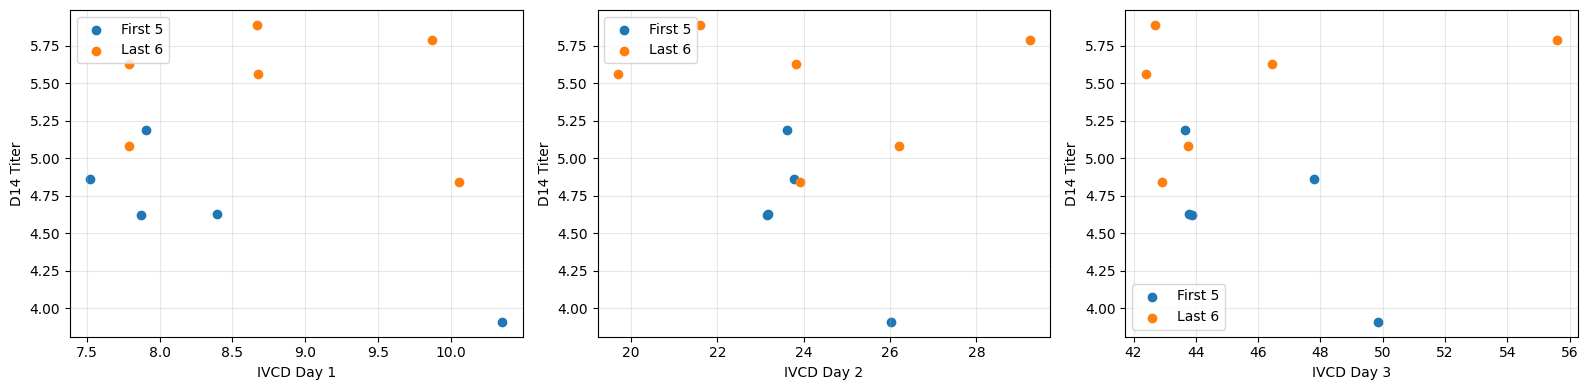

In [22]:
fig, axs = plt.subplots(1, 3, figsize = (16, 4))

ax = axs[0]
ax.scatter(ivcd["Day 1"][:5], target[:5], label = "First 5")
ax.scatter(ivcd["Day 1"][5:], target[5:], label = "Last 6")
ax.grid(alpha = 0.3)
ax.legend()
ax.set_xlabel("IVCD Day 1")
ax.set_ylabel("D14 Titer")

ax = axs[1]
ax.scatter(ivcd["Day 2"][:5], target[:5], label = "First 5")
ax.scatter(ivcd["Day 2"][5:], target[5:], label = "Last 6")
ax.grid(alpha = 0.3)
ax.legend()
ax.set_xlabel("IVCD Day 2")
ax.set_ylabel("D14 Titer")

ax = axs[2]
ax.scatter(ivcd["Day 3"][:5], target[:5], label = "First 5")
ax.scatter(ivcd["Day 3"][5:], target[5:], label = "Last 6")
ax.grid(alpha = 0.3)
ax.legend()
ax.set_xlabel("IVCD Day 3")
ax.set_ylabel("D14 Titer")

fig.tight_layout()

In [23]:
bolus = nstep_ts[["Batch", "Process Day", "Process Time [h]", "Bolus Feed A Daily Qty [kg]", "Bolus Feed B Daily Qty [kg]"]].copy()
bolus = bolus[
    (~bolus["Bolus Feed A Daily Qty [kg]"].isna()) |
    (~bolus["Bolus Feed B Daily Qty [kg]"].isna())
]
bolus["Feed A Cumulative"] = bolus.groupby("Batch")["Bolus Feed A Daily Qty [kg]"].cumsum()
bolus["Feed B Cumulative"] = bolus.groupby("Batch")["Bolus Feed B Daily Qty [kg]"].cumsum()
bolus

,Batch,Process Day,Process Time [h],Bolus Feed A Daily Qty [kg],Bolus Feed B Daily Qty [kg],Feed A Cumulative,Feed B Cumulative
20,FA001,0,6.820833,40.98,NaN,40.98,NaN
21,FA001,0,7.383889,NaN,4.098,NaN,4.098
38,FA001,1,27.183611,40.96,NaN,81.94,NaN
39,FA001,1,27.807500,NaN,4.097,NaN,8.195
61,FA001,2,50.630556,40.98,NaN,122.92,NaN
...,...,...,...,...,...,...,...
3263,FA011,11,265.488889,NaN,4.634,NaN,55.625
3281,FA011,12,287.615556,46.40,NaN,603.12,NaN
3283,FA011,12,289.035278,NaN,4.636,NaN,60.261
3306,FA011,13,314.666944,46.40,NaN,649.52,NaN


In [24]:
cum_a = bolus[["Batch", "Process Day", "Feed A Cumulative"]].dropna()
cum_b = bolus[["Batch", "Process Day", "Feed B Cumulative"]].dropna()

cum_df = pd.merge(cum_a, cum_b, on = ["Batch", "Process Day"])

corr_df = []
target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"].tolist()

for day in cum_df["Process Day"].unique():
    sub_df = cum_df[cum_df["Process Day"] == day]
    X = sub_df["Feed A Cumulative"].tolist()
    feed_a = abs(np.corrcoef(X, target)[0, 1])
    X = sub_df["Feed B Cumulative"].tolist()
    feed_b = abs(np.corrcoef(X, target)[0, 1])
    
    corr_df.append([day, feed_a, feed_b])
corr_df = pd.DataFrame(corr_df, columns = ["Day", "Feed A", "Feed B"])
corr_df.round(2)

,Day,Feed A,Feed B
0,0,0.22,0.23
1,1,0.22,0.23
2,2,0.22,0.22
3,3,0.22,0.22
4,4,0.22,0.22
5,5,0.22,0.22
6,6,0.22,0.22
7,7,0.22,0.22
8,8,0.22,0.22
9,9,0.22,0.22


In [25]:
cum_df[cum_df["Process Day"] == 0]

,Batch,Process Day,Feed A Cumulative,Feed B Cumulative
0,FA001,0,40.98,4.098
14,FA002,0,41.00,4.099
28,FA003,0,40.94,4.066
42,FA004,0,46.32,4.634
56,FA005,0,46.50,4.634
70,FA006,0,46.52,4.651
84,FA007,0,46.38,4.639
98,FA008,0,46.58,4.656
112,FA009,0,46.40,4.642
126,FA010,0,46.40,4.637


In [26]:
qwe = bolus[["Batch", "Process Day", "Feed A Cumulative", "Feed B Cumulative"]]
qwe = qwe[qwe["Process Day"] == 13]
qwe

,Batch,Process Day,Feed A Cumulative,Feed B Cumulative
275,FA001,13,573.680,NaN
276,FA001,13,NaN,57.386
572,FA002,13,573.078,NaN
573,FA002,13,NaN,57.378
866,FA003,13,572.700,NaN
867,FA003,13,NaN,57.230
1173,FA004,13,648.660,NaN
1175,FA004,13,NaN,64.873
1482,FA005,13,650.900,NaN
1484,FA005,13,NaN,65.059


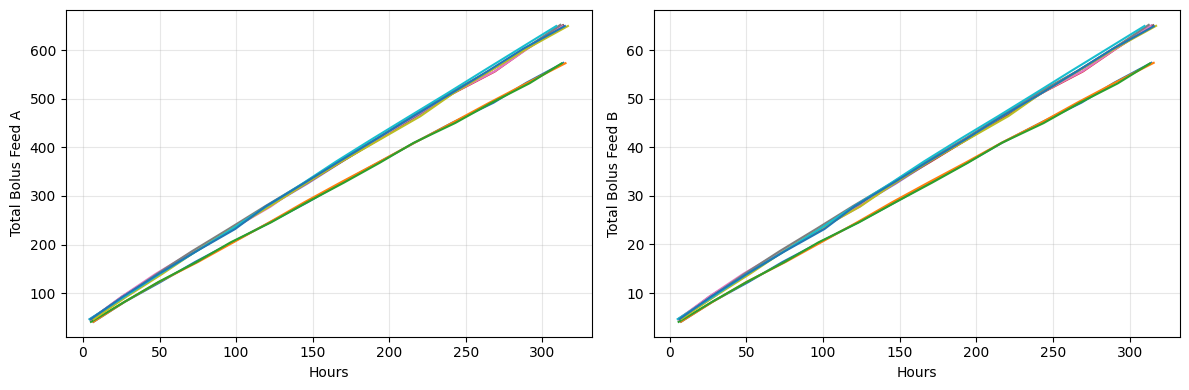

In [27]:
fig, axs = plt.subplots(1, 2, figsize = (12, 4))

for batch in bolus["Batch"].unique():
    sub_df = bolus[bolus["Batch"] == batch].copy()
    sub_df = sub_df[~sub_df["Feed A Cumulative"].isna()]
    ax = axs[0]
    ax.plot(sub_df["Process Time [h]"], sub_df["Feed A Cumulative"])
    ax.set_xlabel("Hours")
    ax.set_ylabel("Total Bolus Feed A")
    ax.grid(alpha = 0.3)
    
    sub_df = bolus[bolus["Batch"] == batch].copy()
    sub_df = sub_df[~sub_df["Feed B Cumulative"].isna()]
    ax = axs[1]
    ax.plot(sub_df["Process Time [h]"], sub_df["Feed B Cumulative"])
    ax.set_xlabel("Hours")
    ax.set_ylabel("Total Bolus Feed B")
    ax.grid(alpha = 0.3)
fig.tight_layout()

In [28]:
nstep_ts_start

,Batch,Process Start Time
0,FA001,49.646944
1,FA002,50.836944
2,FA003,72.782222
3,FA004,50.421667
4,FA005,312.384444
5,FA006,48.570556
6,FA007,218.577222
7,FA008,69.108611
8,FA009,44.972222
9,FA010,94.042778


In [29]:
nstep_minus = pd.read_excel("./data/mCALR N-1.xlsx", sheet_name = 1)
nstep_minus.insert(0, "Batch", nstep_minus["Run"].apply(lambda x: x.split("_")[0]))

nstep_ts_start = nstep_minus[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nstep_ts_start.columns = ["Batch", "Process Start Time"]

nstep_minus = pd.merge(nstep_ts_start, nstep_minus, on = "Batch")
nstep_minus["Process Time [h]"] -= nstep_minus["Process Start Time"]
nstep_minus.insert(3, "Process Day", nstep_minus["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nstep_minus.drop(["Run", "Process Start Time"], axis = 1, inplace = True)

# nstep_minus = nstep_minus[nstep_minus["Batch"].isin([f"FA{str(i).zfill(3)}" for i in range(6, 12)])]

nstep_minus

,Batch,Process Day,Process Time [h],Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
1,FA001,0,0.017778,NaN,NaN,NaN,NaN,NaN,NaN,7.091,NaN,NaN,NaN,NaN,NaN
2,FA001,0,0.019722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,106.0,NaN,NaN,NaN
3,FA001,0,0.021111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.9,NaN,NaN
4,FA001,0,3.514444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,FA011,7,168.748056,NaN,2605.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1200,FA011,7,168.751389,NaN,NaN,NaN,37.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1201,FA011,7,168.753333,NaN,NaN,21.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202,FA011,7,168.757500,NaN,NaN,NaN,NaN,1140.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
nminus_daily = nstep_minus.groupby(["Batch", "Process Day"]).mean().reset_index()
nminus_daily.head()

,Batch,Process Day,Process Time [h],Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,0,2.842796,5.668,4669.45,442.36,5.67,239.04,2.9,7.0835,7.13,102.85,104.2,0.67,99.1
1,FA001,1,22.068773,11.637,4247.83,819.13,18.85,506.20,6.7,7.1080,7.12,79.10,91.1,1.25,99.2
2,FA001,2,46.726995,41.784,3097.91,530.59,22.55,1150.69,10.9,7.0650,7.11,54.10,82.4,2.60,98.5
3,FA001,3,72.079722,28.642,4782.52,506.74,19.55,2015.08,29.5,6.8970,6.97,35.30,52.1,6.06,98.0
4,FA001,4,96.265202,20.666,2867.90,487.66,18.62,1707.63,56.8,6.9200,6.91,47.80,43.1,12.48,97.6


In [31]:
corr_matrix = np.zeros((nminus_daily["Process Day"].nunique(), len(nminus_daily.columns[3:])))

target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"].tolist()
target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"][5:].tolist()

for day in nminus_daily["Process Day"].unique():
    for col_idx, col in enumerate(nminus_daily.columns[3:]):
        X = nminus_daily[nminus_daily["Process Day"] == day][col].tolist()
        corr = np.corrcoef(X, target)[0, 1]
        corr_matrix[day, col_idx] = abs(corr)
        
plt.figure(figsize = (10, 9))
plt.yticks(range(len(nminus_daily.columns[3:])), nminus_daily.columns[3:].tolist())
plt.xticks(range(15))
plt.imshow(corr_matrix.T, vmin = 0.)

for row_idx in range(corr_matrix.shape[0]):
    for col_idx in range(corr_matrix.shape[1]):
        plt.text(row_idx, col_idx, round(corr_matrix[row_idx, col_idx], 2), horizontalalignment = "center")
plt.xlabel("Day")
plt.title("Correlation Between Different Measurements\nOn Final Titer All Batches")
plt.tight_layout()
plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 11 and the array at index 1 has size 6

In [ ]:
last3 = nminus_daily[nminus_daily["Process Day"] >= 5].groupby(["Batch"]).mean().reset_index()
last3
newcorr_df = []

target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"].tolist()
for col in last3.columns[3:]:
    X = last3[col]
    corr = np.corrcoef(X, target)[0, 1]
    newcorr_df.append([col, round(corr, 2), round(abs(corr), 2)])

newcorr_df = pd.DataFrame(newcorr_df, columns = ["Feature", "All Corr", "All Abs Corr"])
newcorr_df

In [ ]:
last3 = nminus_daily[nminus_daily["Process Day"] >= 5].groupby(["Batch"]).mean().reset_index()
last3
corr_df = []

target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"][5:].tolist()
for col in last3.columns[3:]:
    X = last3[col]
    corr = np.corrcoef(X, target)[0, 1]
    corr_df.append([col, round(corr, 2), round(abs(corr), 2)])

corr_df = pd.DataFrame(corr_df, columns = ["Feature", "Last 6 Corr", "Last 6 Abs Corr"])
corr_df

In [ ]:
last_df = pd.merge(corr_df, newcorr_df, on = "Feature")
last_df.to_csv("sample.csv")

In [ ]:
nminus_daily

In [ ]:
target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]["STR2K_D14_4_1_PA_HPLC_Concentration"].tolist()



fig, axs = plt.subplots(3, 3, figsize = (20, 7))

for row_idx in range(3):
    qwe = nminus_daily[nminus_daily["Process Day"] == row_idx + 5]
    
    ax = axs[row_idx][0]
    # plt.scatter(qwe["Viability [%]"][:5], target[:5], label = "First 5")
    ax.scatter(qwe["Viability [%]"][5:], target[5:], label = "Last 6")
    ax.legend()
    ax.grid(alpha = 0.3)
    ax.set_xlabel(f"Viability Day {row_idx + 5}")
    ax.set_ylabel("D14 Titer")
    
    ax = axs[row_idx][1]
    ax.scatter(qwe["Viability [%]"][:5], target[:5], label = "First 5")
    ax.scatter(qwe["Viability [%]"][5:], target[5:], label = "Last 6")
    
    for i in range(11):
        if qwe["Viability [%]"].tolist()[i] < 92:
            ax.text(qwe["Viability [%]"].tolist()[i], target[i], f"FA{str(i + 1).zfill(3)}")
    
    ax.legend()
    ax.grid(alpha = 0.3)
    ax.set_xlabel(f"Viability Day {row_idx + 5}")
    ax.set_ylabel("D14 Titer")
    
    
    ax = axs[row_idx][2]
    ax.scatter(qwe["Viability [%]"][2:], target[2:], label = "FA003 - FA011")
    # ax.scatter(qwe["Viability [%]"][2:], target[2:], label = "Last 6")
    
    for i in range(2, 11):
        # if qwe["Viability [%]"].tolist()[i] < 92:
        ax.text(qwe["Viability [%]"].tolist()[i], target[i], f"FA{str(i + 1).zfill(3)}", rotation = 45)
    
    ax.legend()
    ax.grid(alpha = 0.3)
    ax.set_xlabel(f"Viability Day {row_idx + 5}")
    ax.set_ylabel("D14 Titer")

fig.tight_layout()